# `CPPStructurePlot.explore`

The **integrated** explorer: instead of writing the `predictor(sequence, p1)` callable yourself, pass a feature set `df_feat`, a labeled training population (`df_seq` + `labels`), and a `model`. `explore` builds a built-in per-site predictor that, for each P1 site, computes the query window's feature values for the **fixed** feature set (no `CPP.run` rediscovery), predicts its probability, and attaches the per-site SHAP impact (a default `ShapModel` refit), then renders it. One `output=` argument selects the form:

- `output='widget'` &rarr; a live `ipywidgets` explorer (the P1 slider re-predicts per site).
- `output='html'` &rarr; a self-contained linked HTML page (write it with `path=`).
- `output='static'` &rarr; the structure beside the feature map (a `CombinedView`).

This is a `pro` feature (needs `biopython` + `py3Dmol` + `shap`; the widget also needs `ipywidgets`).

In [1]:
import numpy as np
import pandas as pd
import aaanalysis as aa
import aaanalysis.utils as ut

aa.options["verbose"] = False

## Inputs: a feature set, a training population, and a query protein

`df_feat` fixes **which** features are computed per site (the `PART-SPLIT-SCALE` ids plus the scale-info columns the feature map needs). `df_seq` + `labels` are the labeled windows the predictor learns from; the geometry (`tmd_len`, and the construction `jmd_n_len` / `jmd_c_len`) must match how the features were generated. `sequence` is the query protein the P1 site ranges over.

In [2]:
# A complete CPP-style feature set over real scales / categories
df_scales = aa.load_scales(name="scales")
df_cat = aa.load_scales(name="scales_cat")
df_cat = df_cat[df_cat[ut.COL_SCALE_ID].isin(df_scales.columns)].head(4).reset_index(drop=True)
splits = ["Segment(1,2)", "Segment(2,2)", "Segment(1,1)", "Pattern(C,1)"]
parts = ["TMD", "TMD", "JMD_N", "TMD"]
df_feat = pd.DataFrame({
    ut.COL_FEATURE: [f"{parts[i]}-{splits[i]}-{df_cat[ut.COL_SCALE_ID][i]}" for i in range(4)],
    "category": df_cat[ut.COL_CAT], "subcategory": df_cat[ut.COL_SUBCAT],
    "scale_name": df_cat[ut.COL_SCALE_NAME],
    "abs_auc": [0.2, 0.15, 0.3, 0.1], "abs_mean_dif": [0.3, 0.2, 0.5, 0.4],
    "mean_dif": [0.3, -0.2, 0.5, -0.4], "std_test": 0.1, "std_ref": 0.1})

# A small labeled training population (position-based df_seq: 1-based tmd_start / tmd_stop)
rng = np.random.default_rng(0)
AAs = list("ACDEFGHIKLMNPQRSTVWY")
df_seq = pd.DataFrame([{ut.COL_ENTRY: f"P{i:03d}",
                        ut.COL_SEQ: "".join(rng.choice(AAs, size=40)),
                        ut.COL_TMD_START: 11, ut.COL_TMD_STOP: 20} for i in range(16)])
labels = [1, 0] * 8

# The query protein (human lysozyme C, UniProt P61626) the P1 site slides over
sequence = ("MKALIVLGLVLLSVTVQGKVFERCELARTLKRLGMDGYRGISLANWMCLAKWESGYNTRATNYNAGDRSTDYGIFQINS"
            "RYWCNDGKTPGAVNACHLSCSALLQDNIADAVACAKRVVRDPQGIRAWVAWRNRCQNRDVRQYVQGCGV")
aa.display_df(df_feat, n_rows=10, show_shape=True)

DataFrame shape: (4, 9)


,feature,category,subcategory,scale_name,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref
1,"TMD-Segment(1,2)-LINS030110",ASA/Volume,Accessible surface area (ASA),ASA (folded coil/turn),0.200000,0.300000,0.300000,0.100000,0.100000
2,"TMD-Segment(2,2)-LINS030113",ASA/Volume,Accessible surface area (ASA),ASA (folded coil/turn),0.150000,0.200000,-0.200000,0.100000,0.100000
3,"JMD_N-Segment(1,1)-JANJ780101",ASA/Volume,Accessible surface area (ASA),ASA (folded protein),0.300000,0.500000,0.500000,0.100000,0.100000
4,"TMD-Pattern(C,1)-JANJ780103",ASA/Volume,Accessible surface area (ASA),ASA (folded protein),0.100000,0.400000,-0.400000,0.100000,0.100000


## `output='static'`: a publication side-by-side

The built-in predictor runs once for the chosen `init_site` (a P1 site; `p1` is the first TMD residue, so the window's TMD spans `[p1, p1 + tmd_len - 1]`). `model` accepts a name (`'rf'`, `'svm'`, `'log_reg'`), a scikit-learn estimator, or a list; the `ShapModel` that computes the impact always uses its own defaults. `mode` (`impact`/`plddt`), `focus` (`whole`/`fade`/`zoom`), `size_by_impact`, and `normalize_by_span` style the structure.


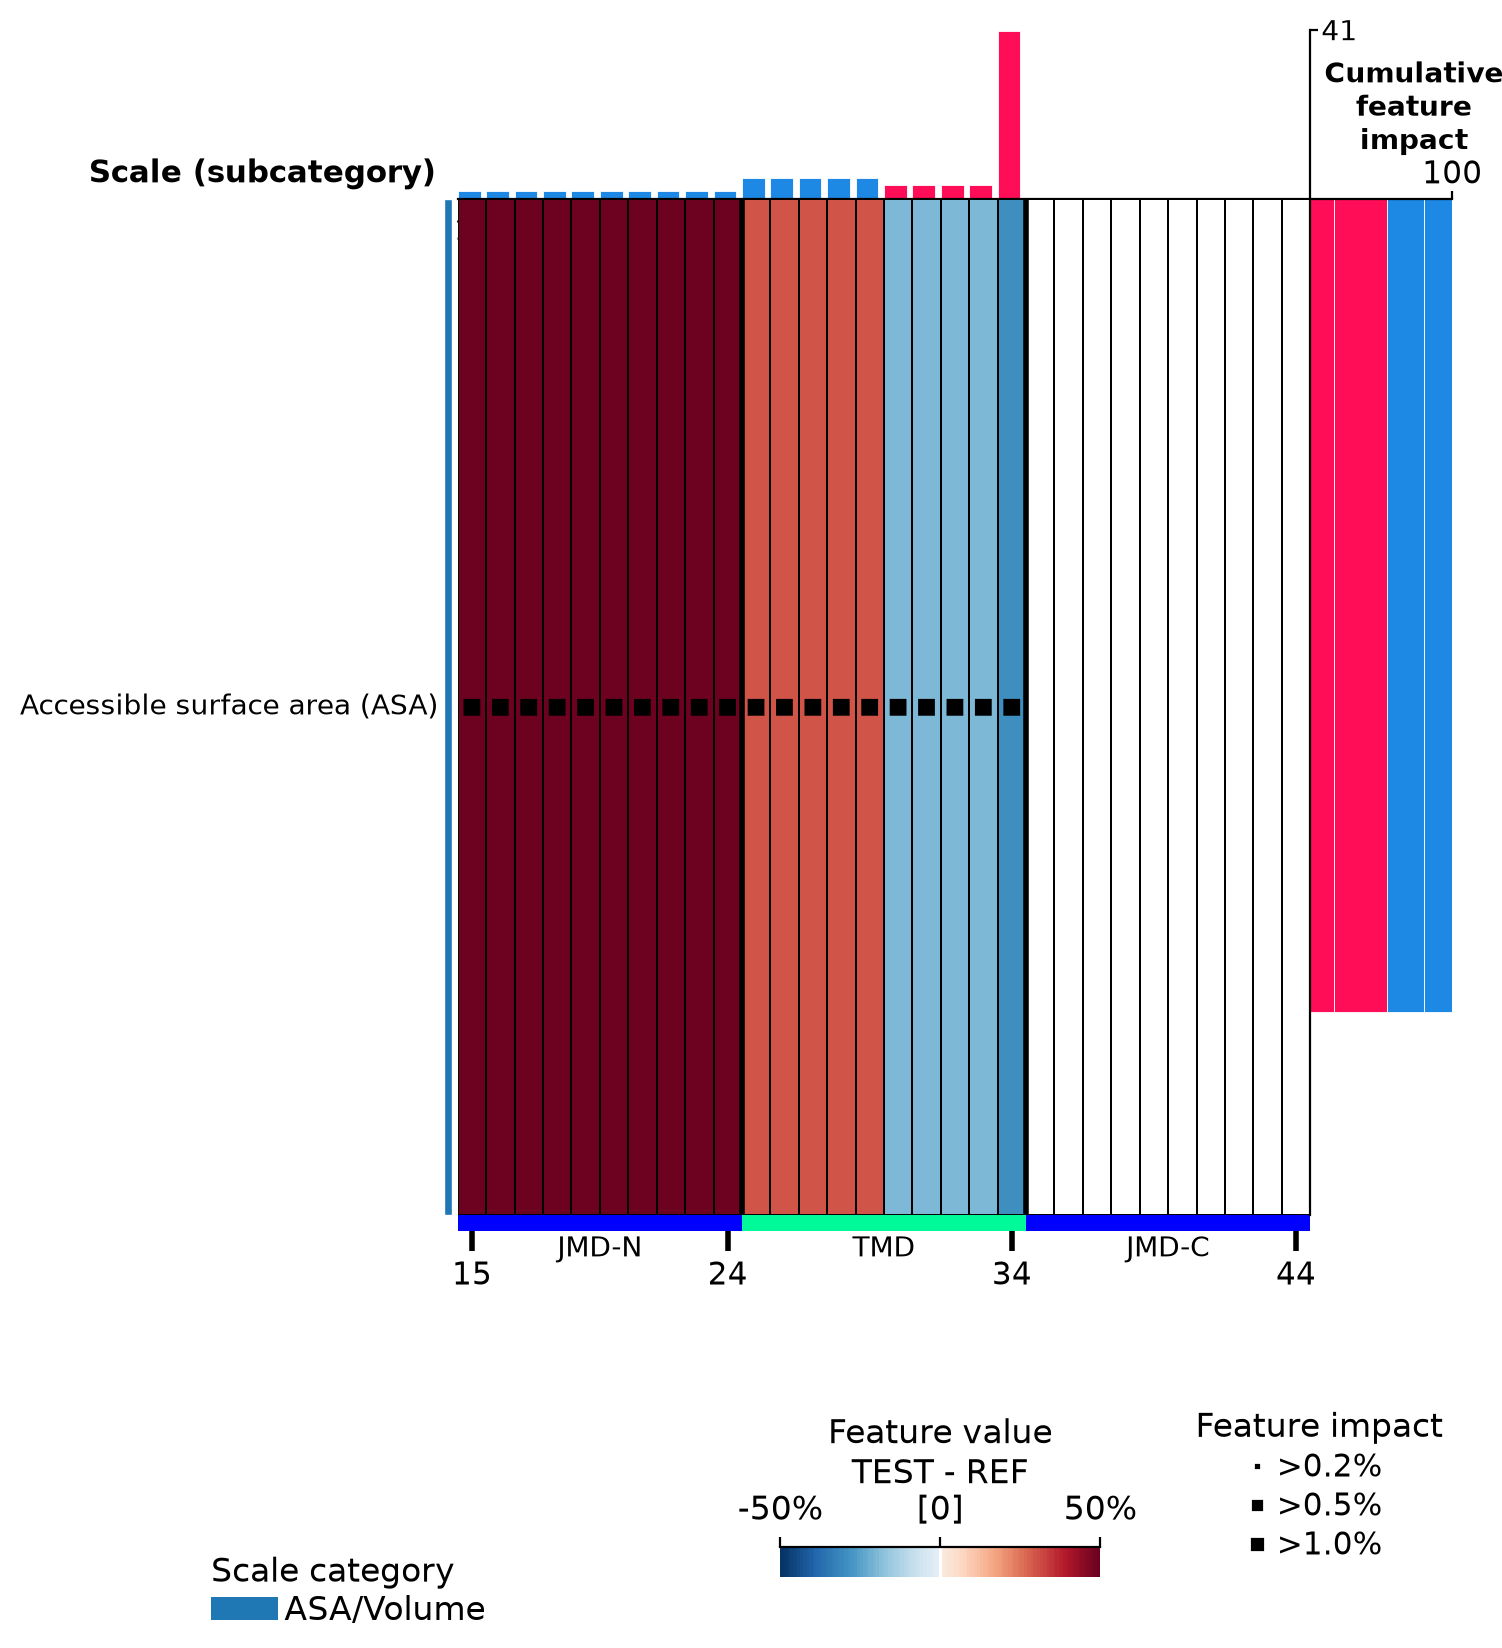

In [3]:
csp = aa.CPPStructurePlot(jmd_n_len=10, jmd_c_len=10, verbose=False)
view = csp.explore(df_feat=df_feat, sequence=sequence, uniprot="P61626",
                   df_seq=df_seq, labels=labels, model="rf", output="static",
                   tmd_len=10, init_site=25, mode="impact", focus="zoom",
                   size_by_impact=True, random_state=42)
view

## `output='html'`: a shareable, self-contained page

Writes one standalone `.html` (feature map &harr; structure hover-linked) to `path` &mdash; the paper-figure / sharing artifact. Baked for the single `init_site` (no live kernel).


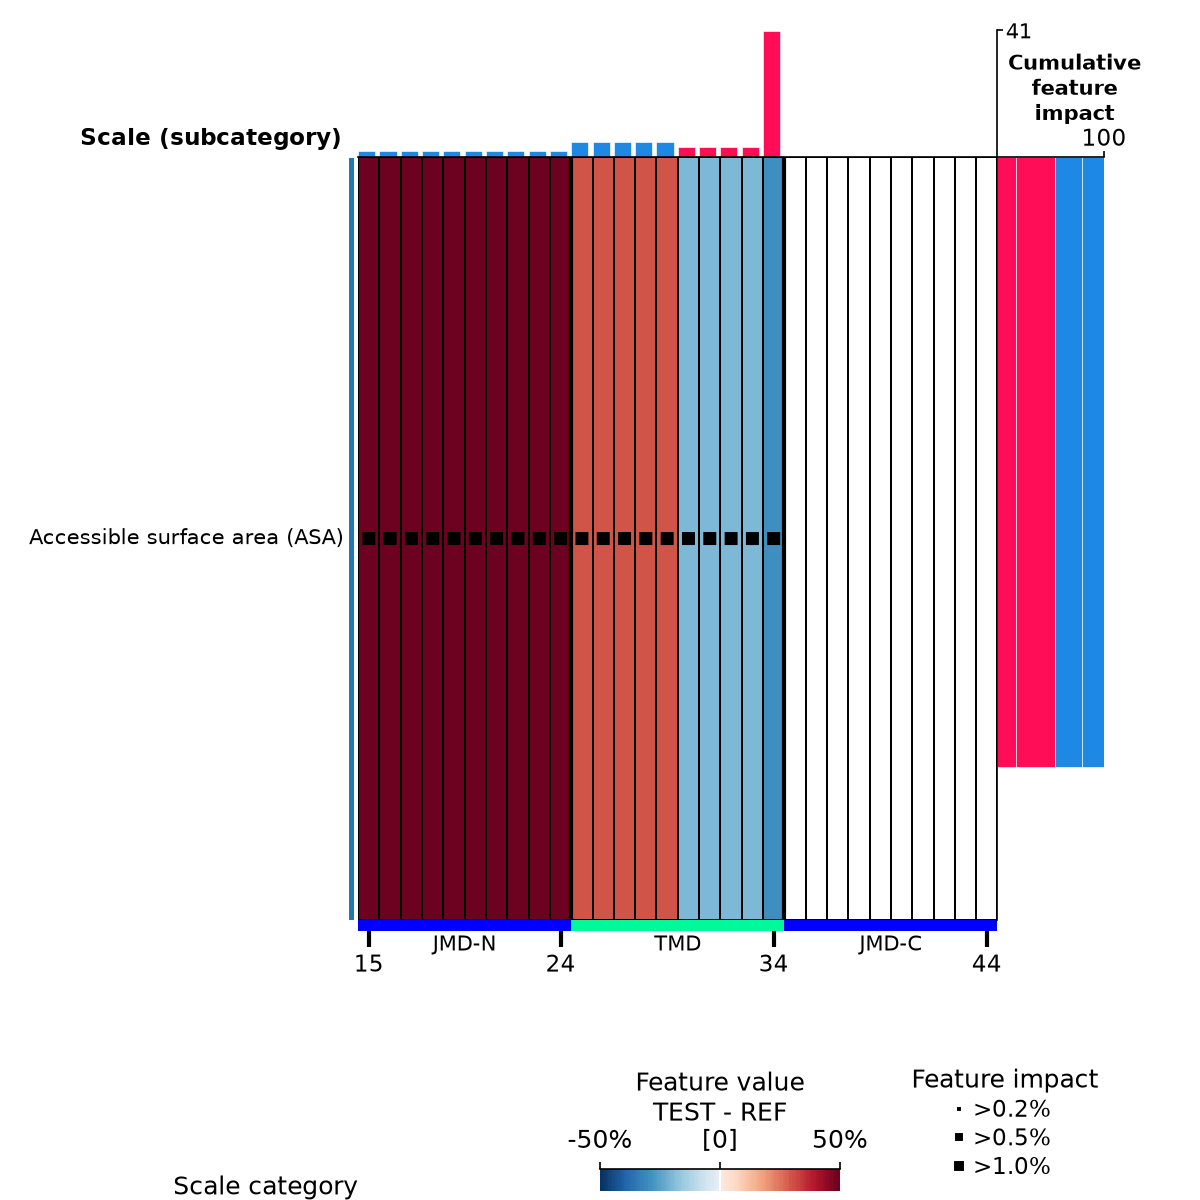

In [4]:
view_html = csp.explore(df_feat=df_feat, sequence=sequence, uniprot="P61626",
                        df_seq=df_seq, labels=labels, model="rf", output="html",
                        path="explore_lysozyme.html", tmd_len=10, init_site=25,
                        random_state=42)
view_html

## `output='html', sites=[...]`: the app-like *live* page

Pass a list of P1 `sites` to bake them all into **one** standalone HTML with a client-side **site slider**: moving it switches the pre-computed prediction per site (feature map + structure restyle) with no kernel, keeping the column&harr;residue linking. Each site embeds a feature-map image and costs one predictor refit (a warning fires past 40 sites; a hard cap at 200).

In [5]:
live = csp.explore(df_feat=df_feat, sequence=sequence, uniprot="P61626",
                   df_seq=df_seq, labels=labels, model="rf", output="html",
                   sites=[40, 55, 70, 85], path="explore_lysozyme_live.html",
                   tmd_len=10, random_state=42)
live

## `output='widget'`: the live explorer

Drag the **site (P1)** slider to re-predict and repaint both views on a live kernel; the colour / focus dropdowns restyle the structure, and `debounce_ms` coalesces rapid moves. `init_site` sets the initial slider site (default near the middle of `sequence`).

In [6]:
panel = csp.explore(df_feat=df_feat, sequence=sequence, uniprot="P61626",
                    df_seq=df_seq, labels=labels, model="rf", output="widget",
                    tmd_len=10, init_site=25, mode="impact", focus="fade",
                    debounce_ms=250, random_state=42)
panel

## Escape hatch: a custom predictor

Pass your own `predictor=(sequence, p1) -> df_feat` to bypass the built-in (then `df_seq` / `labels` / `model` are ignored) &mdash; for a bespoke windowing or model. The lower-level `CPPStructurePlot.interactive`, `plot_linked`, and `plot_combined` remain available when you already hold a `df_feat`.


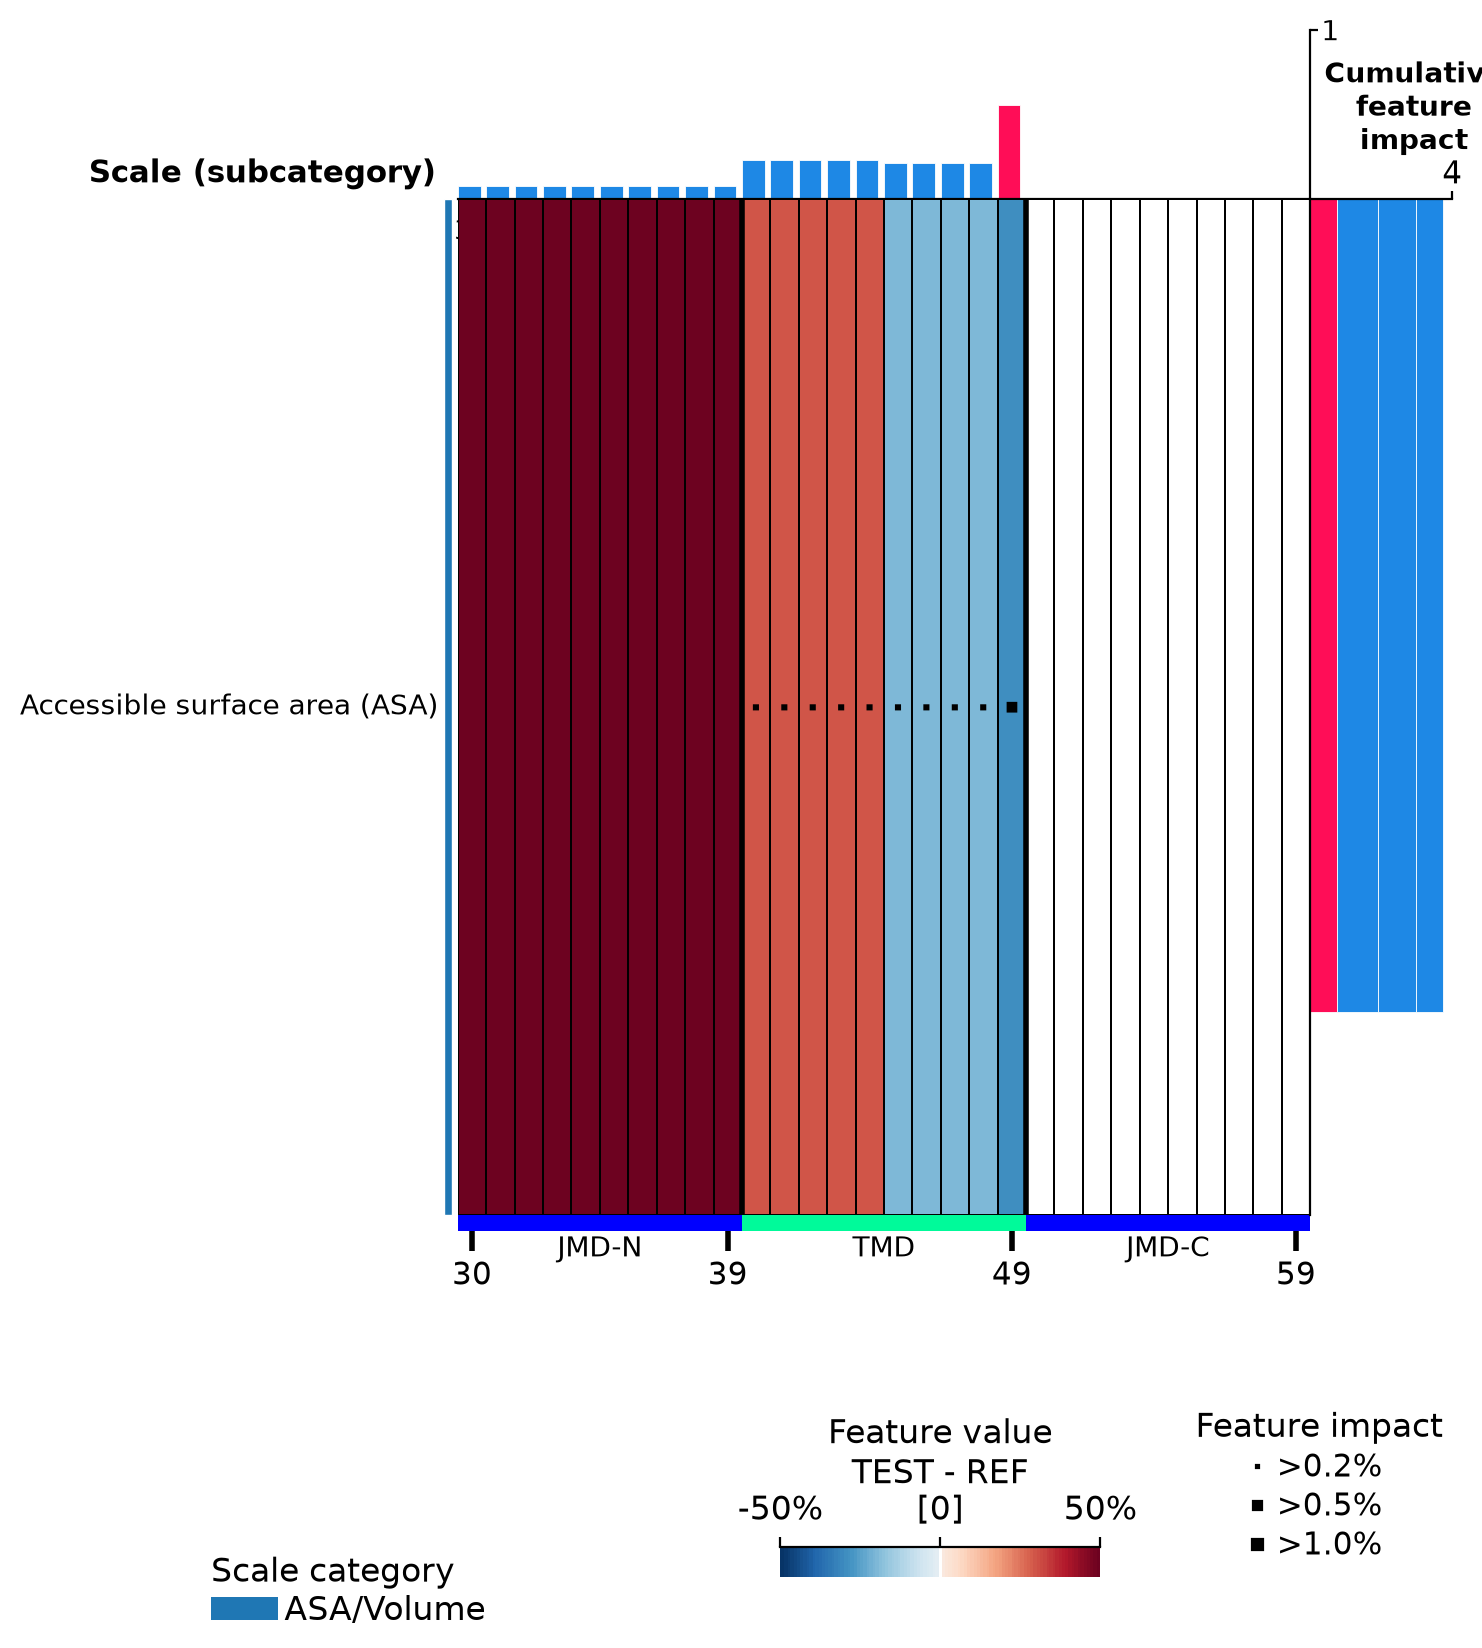

In [7]:
# A custom predictor is any (sequence, p1) -> df_feat callable; here a stand-in for YOUR model.
# With predictor= given, df_seq / labels / model are ignored.
def my_predictor(sequence, p1):
    out = df_feat.copy()
    out['feat_impact'] = np.random.default_rng(p1).normal(size=len(out))  # replace with your model
    return out

csp.explore(df_feat=df_feat, sequence=sequence, uniprot='P61626', predictor=my_predictor,
            output='static', tmd_len=10, init_site=40, label_target_class=1)